In [1]:
import torch

In [6]:

import torch
from torch import nn

import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, input_dim=1769, image_channel=1, hidden_dim=256):
        super(Generator, self).__init__()
        self.input_dim = input_dim

        self.gen = nn.Sequential(
            self._generator_block(input_dim, hidden_dim * 8, kernel_size=5, stride=5),                   # (1x1) → (5x5)
            self._generator_block(hidden_dim * 8, hidden_dim * 4, kernel_size=5, stride=3, padding=1),   # (5x5) → (10x10)
            self._generator_block(hidden_dim * 4, hidden_dim, kernel_size=5, stride=2, padding=1),   # (10x10) → (21x21)
           # self._generator_block(hidden_dim * 2, hidden_dim, kernel_size=4, stride=2, padding=1),       # (21x21) → (42x42)
            self._generator_block(hidden_dim, hidden_dim // 2, kernel_size=3, stride=2, padding=0),   # (42x42) → (85x85)
            self._generator_block(hidden_dim // 2, hidden_dim // 8, kernel_size=4, stride=2, padding=1), #,   # (85x85) → (170x170)
            self._generator_block(hidden_dim // 8, hidden_dim // 256, kernel_size=2, stride=1, padding=1, final_layer=True)#,   # (170x170) → (255x255)
            #self._generator_block(hidden_dim // 8, hidden_dim // 16, kernel_size=4, stride=1, padding=0),  # (255x255) → (272x272)
            #self._generator_block(hidden_dim // 16, hidden_dim // 32, kernel_size=4, stride=1, padding=0),  # (272x272) → (300x300)
            #self._generator_block(hidden_dim // 32, image_channel, kernel_size=4, stride=1, padding=0),  # (300x300) → (340x340)
        )

    def _generator_block(self, input_channels, output_channels, kernel_size=3, stride=2, padding=0, final_layer=False):
        if not final_layer:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride, padding),
                nn.BatchNorm2d(output_channels),
                nn.ReLU(inplace=True),
            )
        else:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride, padding),
                nn.Tanh(),
            )

    def forward(self, noise):
        x = noise.view(len(noise), self.input_dim, 1, 1)
        return self.gen(x)


def create_noise_vector(n_samples, input_dim, device="cpu"):
    return torch.randn(n_samples, input_dim, device=device)

torch.Size([32, 896, 125, 125])
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, image_channel=1, hidden_dim=64):
        super(Discriminator, self).__init__()
        self.disc = nn.Sequential(
            self._discriminator_block(image_channel, hidden_dim),
            self._discriminator_block(hidden_dim, hidden_dim * 2),
            self._discriminator_block(hidden_dim * 2, 1, final_layer=True),
        )

    def _discriminator_block(
        self,
        input_channels,
        output_channels,
        kernel_size=4,
        stride=2,
        final_layer=False,
    ):

        if not final_layer:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride),
                nn.BatchNorm2d(output_channels),
                nn.Dropout(0.3),
                nn.LeakyReLU(0.2, inplace=True),
            )
        else:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride),
            )

    def forward(self, image):
        disc_pred = self.disc(image)
        return disc_pred.view(len(disc_pred), -1)


import torch
from torch import nn
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F

torch.manual_seed(0)  # Set for our testing purposes, please do not change!


def plot_images_from_tensor(image_tensor, num_images=25, size=(1, 28, 28), nrow=5, show=True):
    """
    Plots a grid of images from a given tensor.

    The function first scales the image tensor to the range [0, 1]. It then detaches the tensor from the computation
    graph and moves it to the CPU if it's not already there. After that, it creates a grid of images and plots the grid.

    Args:
        image_tensor (torch.Tensor): A 4D tensor containing the images.
            The tensor is expected to be in the shape (batch_size, channels, height, width).
        num_images (int, optional): The number of images to include in the grid. Default is 25.
        size (tuple, optional): The size of a single image in the form of (channels, height, width). Default is (1, 28, 28).
        nrow (int, optional): Number of images displayed in each row of the grid. The final grid size is (num_images // nrow, nrow). Default is 5.
        show (bool, optional): Determines if the plot should be shown. Default is True.

    Returns:
        None. The function outputs a plot of a grid of images.
    """

    # Normalize the image tensor to [0, 1]
    image_tensor = (image_tensor + 1) / 2

    # Detach the tensor from its computation graph and move it to the CPU
    image_unflat = image_tensor.detach().cpu()

    # Create a grid of images using the make_grid function from torchvision.utils
    image_grid = make_grid(image_unflat[:num_images], nrow=nrow)

    # Plot the grid of images
    # The permute() function is used to rearrange the dimensions of the grid for plotting
    plt.imshow(image_grid.permute(1, 2, 0).squeeze())

    # Show the plot if the 'show' parameter is True
    if show:
        plt.show()

    



""" The reason for doing "image_grid.permute(1, 2, 0)"

PyTorch modules processing image data expect tensors in the format C × H × W.

Whereas PILLow and Matplotlib expect image arrays in the format H × W × C

so to use them with matplotlib you need to reshape it
to put the channels as the last dimension:

I could have used permute() method as well like below
"np.transpose(npimg, (1, 2, 0))"

------------------

Tensor.detach() is used to detach a tensor from the current computational graph. It returns a new tensor that doesn't require a gradient.

When we don't need a tensor to be traced for the gradient computation, we detach the tensor from the current computational graph.

We also need to detach a tensor when we need to move the tensor from GPU to CPU.

"""


def weights_init(m):
    """
    Initialize the weights of convolutional and batch normalization layers.

    Args:
        m (torch.nn.Module): Module instance.

    """
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
        torch.nn.init.constant_(m.bias, 0)


def ohe_vector_from_labels(labels, n_classes):
    return F.one_hot(labels, num_classes=n_classes)


"""
x = torch.tensor([4, 3, 2, 1, 0])
F.one_hot(x, num_classes=6)

# Expected result
# tensor([[0, 0, 0, 0, 1, 0],
#         [0, 0, 0, 1, 0, 0],
#         [0, 0, 1, 0, 0, 0],
#         [0, 1, 0, 0, 0, 0],
#         [1, 0, 0, 0, 0, 0]])
"""


""" Concatenation of Multiple Tensor with `torch.cat()` - RULE - To concatenate WITH torch.cat(), where the list of tensors are concatenated across the specified dimensions, requires 2 conditions to be satisfied

1. All tensors need to have the same number of dimensions and
2. All dimensions except the one that they are concatenated on, need to have the same size. """


def concat_vectors(x, y):
    """
    Concatenate two tensors along the second dimension.

    Args:
        x (torch.Tensor): First input tensor.
        y (torch.Tensor): Second input tensor.

    Returns:
        torch.Tensor: Concatenated tensor.

    """
    combined = torch.cat((x.float(), y.float()), 1)
    return combined

def calculate_input_dim(z_dim, mnist_shape, n_classes):
    """
    Calculate the input dimensions for the generator and discriminator networks.

    Args:
        z_dim (int): Dimension of the random noise vector (latent space).
        mnist_shape (tuple): Shape of the MNIST images, e.g., (1, 28, 28).
        n_classes (int): Number of classes in the dataset.

    Returns:
        tuple: Tuple containing the generator input dimension and discriminator image channel.

    mnist_shape = (1, 28, 28)
    n_classes = 10"""
    generator_input_dim = z_dim + n_classes

    # mnist_shape[0] is 1 as its grayscale images
    discriminator_image_channel = 1 + n_classes

    return generator_input_dim, discriminator_image_channel


import torch
from torch import nn
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

#from conditional_gan import *
#from utils import *

mnist_shape = (1, 125, 125)
n_classes = 768


criterion = nn.BCEWithLogitsLoss()
n_epochs = 1
z_dim = 1001
display_step = 25
batch_size = 48
lr = 0.0002
device = "cuda"

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)


In [7]:


#dataloader = DataLoader(
#    MNIST(
#        "/home/dennis00/scRNA_GAN/MNIST", download=True, transform=transform
#    ),
#    batch_size=batch_size,
#    shuffle=True,
#)

generator_input_dim, discriminator_image_channel = calculate_input_dim(
    z_dim, mnist_shape, n_classes
)

gen = Generator(input_dim=generator_input_dim).to(device)

gen_opt = torch.optim.Adam(gen.parameters(), lr=lr)

disc = Discriminator(image_channel=discriminator_image_channel).to(device)

disc_opt = torch.optim.Adam(disc.parameters(),  lr=0.0001, betas=(0.5, 0.999))

def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        torch.nn.init.normal_(m.weight, 0.0, 0.02)
        torch.nn.init.constant_(m.bias, 0)


gen  = gen.apply(weights_init)

disc = disc.apply(weights_init)


cur_step = 0
generator_losses = []
discriminator_losses = []

noise_and_labels = False
fake = False

fake_image_and_labels = False
real_image_and_labels = False
disc_fake_pred = False
disc_real_pred = False


In [10]:

gen.load_state_dict(torch.load("../GAN_models/generator_OneKEmbed_Img125.pth"))
disc.load_state_dict(torch.load("../GAN_models/discriminator_OneKEmbed_Img125.pth"))

gen_opt.load_state_dict(torch.load("../GAN_models/generator_optimizer_OneKEmbed_Img125.pth"))
disc_opt.load_state_dict(torch.load("../GAN_models/discriminator_optimizer_OneKEmbed_Img125.pth"))

gen.eval()  # Set to evaluation mode

Generator(
  (gen): Sequential(
    (0): Sequential(
      (0): ConvTranspose2d(1769, 2048, kernel_size=(5, 5), stride=(5, 5))
      (1): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): ConvTranspose2d(2048, 1024, kernel_size=(5, 5), stride=(3, 3), padding=(1, 1))
      (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): ConvTranspose2d(1024, 256, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (3): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (4): Sequential(
      (0): ConvTranspose

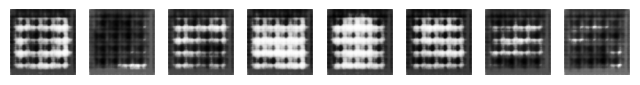

In [17]:
import matplotlib.pyplot as plt

def generate_images(label_idx, num_samples=8):
    """
    Generates and plots fake images for a given label index.
    
    Args:
    - label_idx (int): The class label index to generate images for.
    - num_samples (int): The number of images to generate.
    """
    # Create random noise vectors
    noise = create_noise_vector(num_samples, z_dim, device=device)

    # Create one-hot encoded labels
    one_hot_labels = torch.zeros((num_samples, 768), device=device)
    one_hot_labels[:, label_idx] = 1  # Set the specific label

    # Concatenate noise with labels
    noise_and_labels = concat_vectors(noise, one_hot_labels)

    # Generate fake images
    with torch.no_grad():
        fake_images = gen(noise_and_labels)

    # Plot the generated images
    fig, axes = plt.subplots(1, num_samples, figsize=(num_samples, 2))
    for i, img in enumerate(fake_images.cpu().detach()):
        axes[i].imshow(img.squeeze(0), cmap="gray")  # Adjust for color channels if needed
        axes[i].axis("off")

    plt.show()

# Example: Generate images for label index 3 (change index as needed)
generate_images(label_idx=3, num_samples=8)


In [13]:
noise

tensor([[ 0.4916, -0.5019,  0.7337,  ..., -0.3618, -0.8377,  0.0788]],
       device='cuda:0')